In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/notebooks/tanishksinghthakur/uslproj/arxiv_with_topics.csv
/kaggle/input/notebooks/tanishksinghthakur/uslproj/__results__.html
/kaggle/input/notebooks/tanishksinghthakur/uslproj/__notebook__.ipynb
/kaggle/input/notebooks/tanishksinghthakur/uslproj/__output__.json
/kaggle/input/notebooks/tanishksinghthakur/uslproj/document_topic_matrix.npz
/kaggle/input/notebooks/tanishksinghthakur/uslproj/custom.css
/kaggle/input/notebooks/aryannahata07/research-paper-topic-discovery/tfidf_feature_names.pkl
/kaggle/input/notebooks/aryannahata07/research-paper-topic-discovery/tfidf_vocab.json
/kaggle/input/notebooks/aryannahata07/research-paper-topic-discovery/__results__.html
/kaggle/input/notebooks/aryannahata07/research-paper-topic-discovery/__notebook__.ipynb
/kaggle/input/notebooks/aryannahata07/research-paper-topic-discovery/tfidf_features.npz
/kaggle/input/notebooks/aryannahata07/research-paper-topic-discovery/__output__.json
/kaggle/input/notebooks/aryannahata07/research-paper-topi

In [2]:
import numpy as np
import pandas as pd
from scipy import sparse
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded!")


Libraries loaded!


In [3]:
input_path = "/kaggle/input/notebooks/tanishksinghthakur/uslproj/"

# Load document-topic matrix (papers x 20 topics)
W = sparse.load_npz(input_path + "document_topic_matrix.npz").toarray()

# Load the dataframe
df = pd.read_csv(input_path + "arxiv_with_topics.csv", low_memory=False)

print(f"Document-Topic Matrix Shape: {W.shape}")
print(f"DataFrame Shape: {df.shape}")
print(f"\nTopic Distribution:")
print(df['dominant_topic'].value_counts().sort_index())


Document-Topic Matrix Shape: (2968855, 20)
DataFrame Shape: (2968855, 5)

Topic Distribution:
dominant_topic
0     915638
1     420251
2     325563
3     138888
4      78422
5      88603
6     105933
7     122897
8      68466
9      89425
10     65462
11     70716
12     98174
13     35037
14     52127
15     51662
16     43122
17     51456
18     67031
19     79982
Name: count, dtype: int64


In [4]:
SAMPLE_SIZE = 50000

# Sample proportionally from each topic so all 20 are represented
sampled_indices = []

for topic_id in range(20):
    topic_indices = np.where(df['dominant_topic'] == topic_id)[0]
    topic_proportion = len(topic_indices) / len(df)
    n_samples = max(100, int(SAMPLE_SIZE * topic_proportion))  # at least 100 per topic
    sampled = np.random.choice(topic_indices, size=min(n_samples, len(topic_indices)), replace=False)
    sampled_indices.extend(sampled)

sampled_indices = np.array(sampled_indices)
W_sample = W[sampled_indices]
df_sample = df.iloc[sampled_indices].reset_index(drop=True)

print(f"Total sampled: {len(sampled_indices)} papers")
print(df_sample['dominant_topic'].value_counts().sort_index())


Total sampled: 49991 papers
dominant_topic
0     15420
1      7077
2      5482
3      2339
4      1320
5      1492
6      1784
7      2069
8      1153
9      1506
10     1102
11     1190
12     1653
13      590
14      877
15      870
16      726
17      866
18     1128
19     1347
Name: count, dtype: int64


In [5]:
from sklearn.manifold import TSNE
import numpy as np

TSNE_SAMPLE = 35000
tsne_idx = np.random.choice(len(df_sample), size=TSNE_SAMPLE, replace=False)
W_tsne = W_sample[tsne_idx]
df_tsne = df_sample.iloc[tsne_idx].reset_index(drop=True)

print(f"Running t-SNE on {TSNE_SAMPLE} papers (takes 10-15 minutes)...")
tsne = TSNE(n_components=2, perplexity=40, random_state=42, n_iter=1000, verbose=1)
tsne_results = tsne.fit_transform(W_tsne)

df_tsne['tsne_x'] = tsne_results[:, 0]
df_tsne['tsne_y'] = tsne_results[:, 1]
print("t-SNE complete!")


Running t-SNE on 35000 papers (takes 10-15 minutes)...
[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 35000 samples in 0.001s...
[t-SNE] Computed neighbors for 35000 samples in 4.419s...
[t-SNE] Computed conditional probabilities for sample 1000 / 35000
[t-SNE] Computed conditional probabilities for sample 2000 / 35000
[t-SNE] Computed conditional probabilities for sample 3000 / 35000
[t-SNE] Computed conditional probabilities for sample 4000 / 35000
[t-SNE] Computed conditional probabilities for sample 5000 / 35000
[t-SNE] Computed conditional probabilities for sample 6000 / 35000
[t-SNE] Computed conditional probabilities for sample 7000 / 35000
[t-SNE] Computed conditional probabilities for sample 8000 / 35000
[t-SNE] Computed conditional probabilities for sample 9000 / 35000
[t-SNE] Computed conditional probabilities for sample 10000 / 35000
[t-SNE] Computed conditional probabilities for sample 11000 / 35000
[t-SNE] Computed conditional probabilities for sample 12000 / 

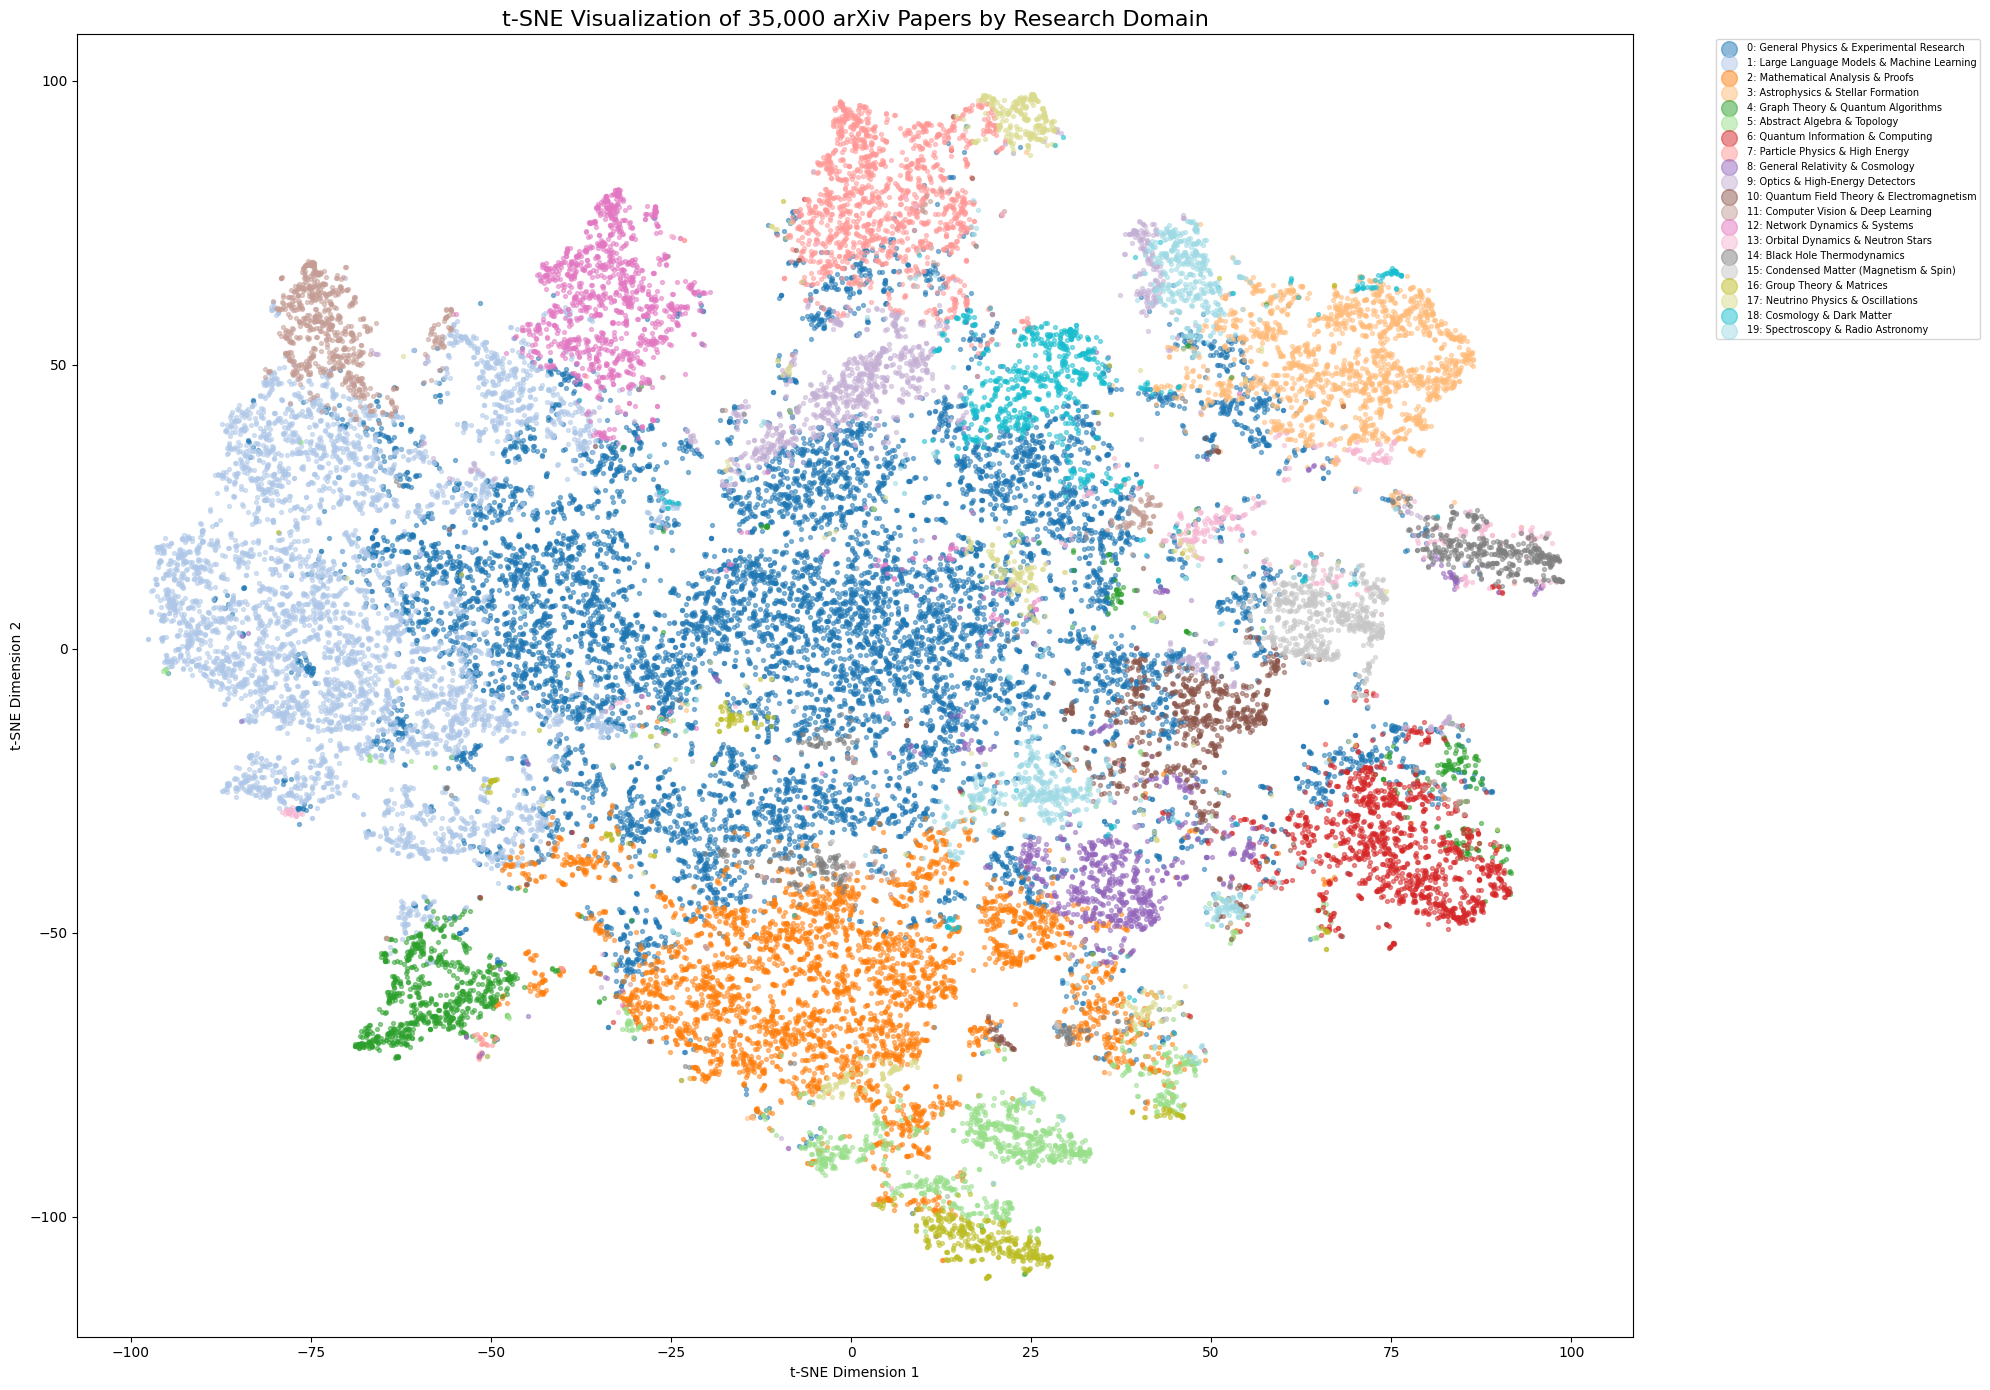

Saved: tsne_labeled.png


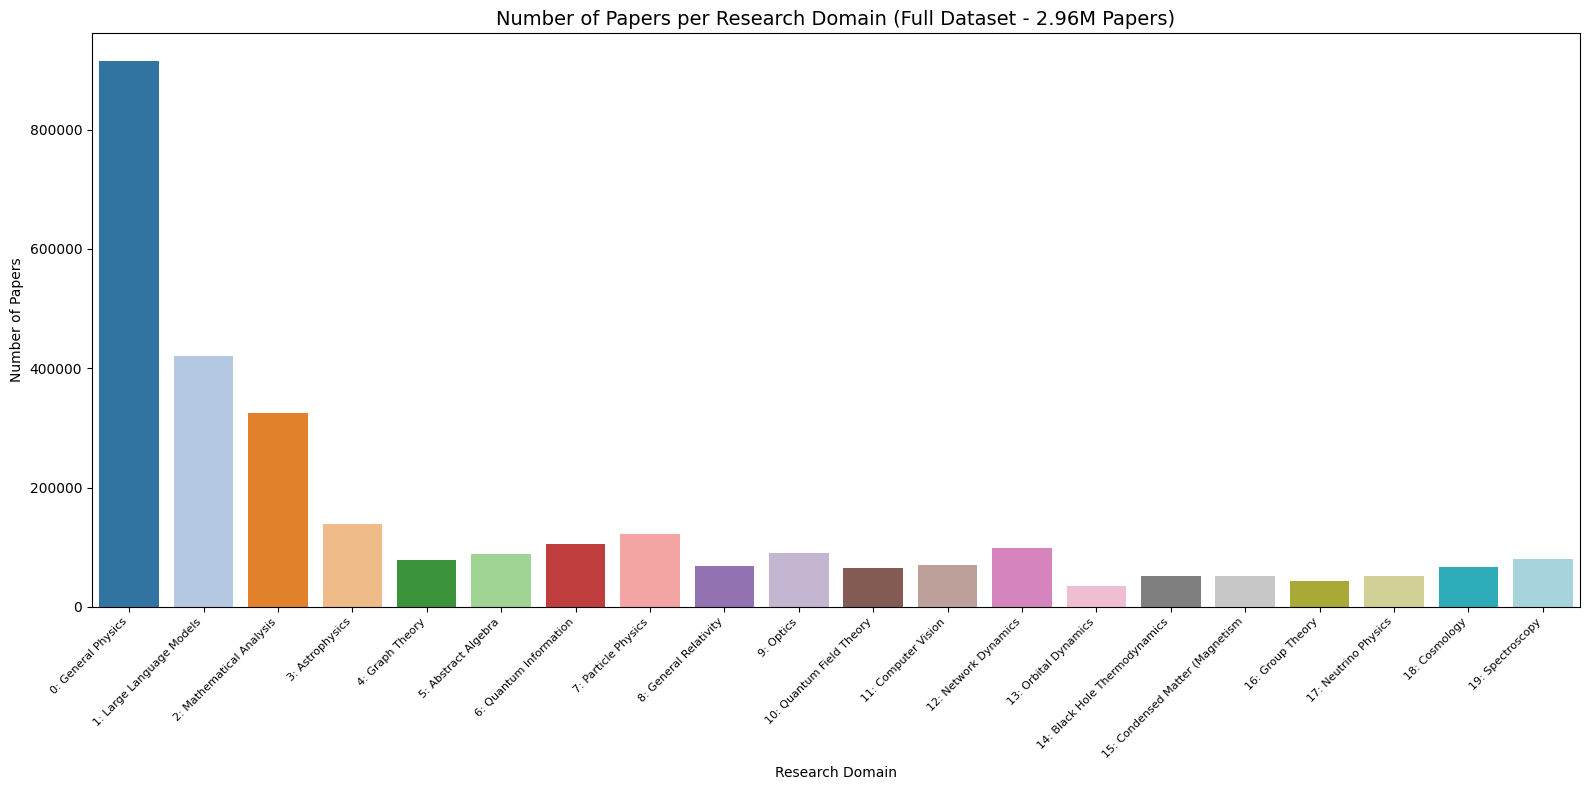

Saved: topic_distribution_labeled.png


In [6]:
topic_mapping = {
    0: "General Physics & Experimental Research",
    1: "Large Language Models & Machine Learning",
    2: "Mathematical Analysis & Proofs",
    3: "Astrophysics & Stellar Formation",
    4: "Graph Theory & Quantum Algorithms",
    5: "Abstract Algebra & Topology",
    6: "Quantum Information & Computing",
    7: "Particle Physics & High Energy",
    8: "General Relativity & Cosmology",
    9: "Optics & High-Energy Detectors",
    10: "Quantum Field Theory & Electromagnetism",
    11: "Computer Vision & Deep Learning",
    12: "Network Dynamics & Systems",
    13: "Orbital Dynamics & Neutron Stars",
    14: "Black Hole Thermodynamics",
    15: "Condensed Matter (Magnetism & Spin)",
    16: "Group Theory & Matrices",
    17: "Neutrino Physics & Oscillations",
    18: "Cosmology & Dark Matter",
    19: "Spectroscopy & Radio Astronomy"
}

colors = cm.get_cmap('tab20', 20)

# --- Labeled t-SNE Plot ---
plt.figure(figsize=(20, 14))
for topic_id in range(20):
    mask = df_tsne['dominant_topic'] == topic_id
    plt.scatter(
        df_tsne.loc[mask, 'tsne_x'],
        df_tsne.loc[mask, 'tsne_y'],
        c=[colors(topic_id)],
        label=f"{topic_id}: {topic_mapping[topic_id]}",
        alpha=0.5,
        s=8
    )
plt.title('t-SNE Visualization of 35,000 arXiv Papers by Research Domain', fontsize=16)
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', markerscale=4, fontsize=7)
plt.tight_layout()
plt.savefig('/kaggle/working/tsne_labeled.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: tsne_labeled.png")

# --- Labeled Bar Chart ---
topic_counts = df['dominant_topic'].value_counts().sort_index()
plt.figure(figsize=(16, 8))
labels = [f"{i}: {topic_mapping[i].split('&')[0].strip()}" for i in range(20)]
sns.barplot(x=list(range(20)), y=topic_counts.values, palette='tab20', hue=list(range(20)), legend=False)
plt.xticks(ticks=range(20), labels=labels, rotation=45, ha='right', fontsize=8)
plt.title('Number of Papers per Research Domain (Full Dataset - 2.96M Papers)', fontsize=14)
plt.xlabel('Research Domain')
plt.ylabel('Number of Papers')
plt.tight_layout()
plt.savefig('/kaggle/working/topic_distribution_labeled.png', dpi=150)
plt.show()
print("Saved: topic_distribution_labeled.png")


In [7]:
import pickle
from sklearn.decomposition import MiniBatchNMF

nb2_path = "/kaggle/input/notebooks/aryannahata07/research-paper-topic-discovery/"

print("Loading TF-IDF matrix...")
tfidf_matrix = sparse.load_npz(nb2_path + "tfidf_features.npz")

print("Loading feature names...")
with open(nb2_path + "tfidf_feature_names.pkl", "rb") as f:
    feature_names = pickle.load(f)

print(f"TF-IDF Shape: {tfidf_matrix.shape}")
print(f"Vocabulary size: {len(feature_names)}")

print("\nRetraining NMF (needed for pyLDAvis)...")
nmf_model = MiniBatchNMF(n_components=20, random_state=42, batch_size=1024, max_iter=200)
nmf_model.fit(tfidf_matrix)
print("NMF ready!")


Loading TF-IDF matrix...
Loading feature names...
TF-IDF Shape: (2968855, 10000)
Vocabulary size: 10000

Retraining NMF (needed for pyLDAvis)...
NMF ready!


In [8]:
import pyLDAvis
from sklearn.preprocessing import normalize
import warnings
warnings.filterwarnings('ignore')

print("Preparing pyLDAvis data manually...")

H = nmf_model.components_
topic_term_dists = H / H.sum(axis=1, keepdims=True)

print("Transforming full dataset...")
W_full = nmf_model.transform(tfidf_matrix)

row_sums = W_full.sum(axis=1)
valid_mask = row_sums > 0
W_valid = W_full[valid_mask]
print(f"Removed {(~valid_mask).sum()} zero rows, using {valid_mask.sum()} documents")

doc_topic_dists = normalize(W_valid, norm='l1')
doc_lengths = np.array(tfidf_matrix[valid_mask].sum(axis=1)).flatten().astype(int)
doc_lengths[doc_lengths == 0] = 1
term_frequency = np.array(tfidf_matrix.sum(axis=0)).flatten()

print("Building visualization...")
vis_data = pyLDAvis.prepare(
    topic_term_dists=topic_term_dists,
    doc_topic_dists=doc_topic_dists,
    doc_lengths=doc_lengths,
    vocab=list(feature_names),
    term_frequency=term_frequency,
    mds='tsne',
    sort_topics=False
)

pyLDAvis.save_html(vis_data, '/kaggle/working/lda_vis.html')
print("Saved: lda_vis.html")
pyLDAvis.display(vis_data)


Preparing pyLDAvis data manually...
Transforming full dataset...
Removed 10 zero rows, using 2968845 documents
Building visualization...
Saved: lda_vis.html
